# SpectraAE: Conv Autoencoder → Bottleneck Features → PU-Bagging

**核心思路**：用 1D Conv Autoencoder 在 LAMOST 光谱上无监督预训练，提取 64-d 瓶颈特征，然后用 PU-Bagging 做 CN 星分类。与原始 700 像素光谱做对比。

**关键结论**：AE-64d 压缩率达 10.9x (700→64) 但信息损失严重 — PR=0.167 vs Raw Spectra PR=0.848。瓶颈特征主要学到全局连续谱形状，丢失了 CN 带细节。

**SpectraAE 文件夹各程序功能**：
- `models/autoencoder.py` — 1D Conv AE 架构 (96K 参数)
- `pretrain.py` — 无监督预训练 (MSE 重建损失)
- `extract_features.py` — 提取 64-d 瓶颈特征
- `pu_bagging_ae.py` — PU-Bagging 分类 + Raw Spectra 对比
- `run_ae_pipeline.py` — 端到端流水线


In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Ensure project root in path: running from SpectraAE/ dir
_ROOT = Path().resolve()
if _ROOT.name == 'SpectraAE':
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from SpectraAE.models.autoencoder import ConvAutoencoder
from ML.pu_bagging import load_pu_data
from ML.utils import FEATURE_COLS_CN9

print('Imports OK')


Imports OK


## 1. 数据加载

从 `ML/_cache` 加载预处理后的光谱数据 (33,589 条, 700 像素) 和标签。


In [2]:
# ---- Load spectra ----
CACHE_DIR = _ROOT / 'ML' / '_cache'
X_clean = np.load(CACHE_DIR / 'X_clean.npy').astype(np.float32)
stars_meta = pd.read_pickle(CACHE_DIR / 'stars_clustered.pkl')
print(f'X_clean: {X_clean.shape}')
print(f'  pixel range: [{X_clean.min():.4f}, {X_clean.max():.4f}]')
print(f'  mean={X_clean.mean():.4f}, std={X_clean.std():.4f}')

# ---- Load labels via pu_bagging ----
data = load_pu_data()
y_all = data['y_all']
cluster_ids = data['cluster_ids']
df_model = data['df_model']
pos_mask = y_all == 1
n_pos = int(y_all.sum())
print(f'Labels: {len(y_all):,} stars, {n_pos} known CN positives, {int((y_all==0).sum()):,} unlabeled')


X_clean: (33589, 700)
  pixel range: [-58.4811, 20.7802]
  mean=1.0444, std=0.2370
Labels: 33,589 stars, 73 known CN positives, 33,516 unlabeled


### 光谱预览

展示已知 CN 星 vs 普通星的连续谱归一化光谱对比。CN 带区域有明显吸收差异。


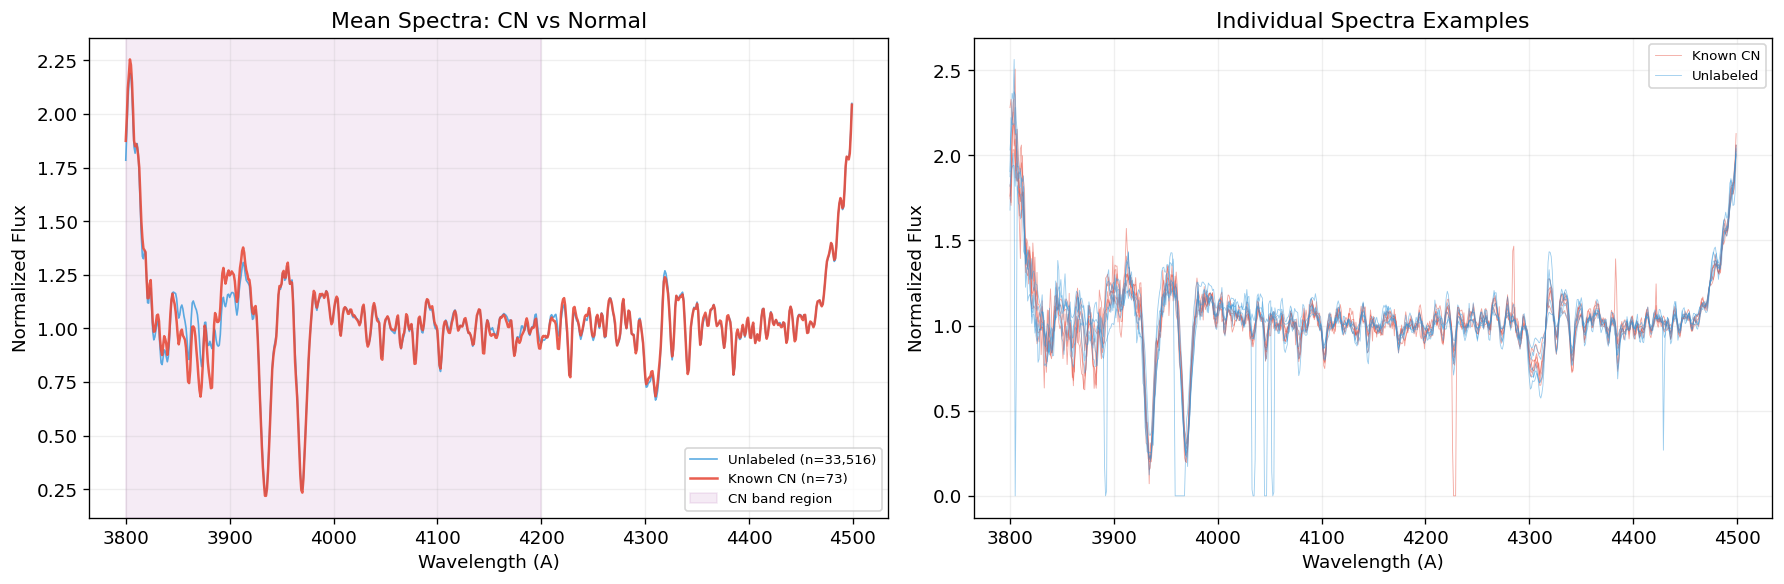

In [3]:
wave = np.arange(3800.0, 4500.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mean spectra
ax = axes[0]
ax.plot(wave, X_clean[~pos_mask].mean(axis=0), alpha=0.8, lw=1,
        color='#3498db', label=f'Unlabeled (n={(~pos_mask).sum():,})')
ax.plot(wave, X_clean[pos_mask].mean(axis=0), alpha=0.9, lw=1.5,
        color='#e74c3c', label=f'Known CN (n={pos_mask.sum()})')
ax.axvspan(3800, 4200, alpha=0.08, color='purple', label='CN band region')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Normalized Flux')
ax.set_title('Mean Spectra: CN vs Normal')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Individual examples
ax = axes[1]
for j, i in enumerate(np.where(pos_mask)[0][:5]):
    ax.plot(wave, X_clean[i], alpha=0.5, lw=0.5, color='#e74c3c',
            label='Known CN' if j == 0 else '')
for j, i in enumerate(np.where(~pos_mask)[0][:5]):
    ax.plot(wave, X_clean[i], alpha=0.5, lw=0.5, color='#3498db',
            label='Unlabeled' if j == 0 else '')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Normalized Flux')
ax.set_title('Individual Spectra Examples')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 2. Autoencoder 模型架构

**Encoder**: Conv1d(1→32→64→128) + ReflectionPad + stride-2 下采样 → AdaptiveAvgPool1d → Linear → 64-d bottleneck

**Decoder**: Linear → 插值上采样 + Conv1d 逐级恢复 → 700px 重建

参数量 ~96K，紧凑轻量。


In [4]:
model_disp = ConvAutoencoder(in_channels=1, base_ch=32, latent_dim=64)
n_params = sum(p.numel() for p in model_disp.parameters())
print(f'Total params: {n_params:,}')
print(f'Compression: 700 -> 64 (10.9x)')
print(model_disp)


Total params: 87,296
Compression: 700 -> 64 (10.9x)
ConvAutoencoder(
  (encoder): Encoder(
    (pad): ReflectionPad1d((2, 2))
    (conv1): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (conv2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (conv3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (pool): AdaptiveAvgPool1d(output_size=1)
    (fc): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=64, out_features=128, bias=True)
    (deco

### Shape 演变 (Encoder → Bottleneck → Decoder)


In [5]:
x_dummy = torch.randn(1, 1, 700)
enc = model_disp.encoder

print('Input:           (1, 1, 700)')
x = enc.pad(x_dummy)
print(f'  After pad:     {tuple(x.shape)}')
x = enc.conv1(x)
print(f'  After conv1:   {tuple(x.shape)}  (32 ch, /2)')
x = enc.conv2(x)
print(f'  After conv2:   {tuple(x.shape)}  (64 ch, /2)')
x = enc.conv3(x)
print(f'  After conv3:   {tuple(x.shape)}  (128 ch, /2)')
x = enc.pool(x)
print(f'  After pool:    {tuple(x.shape)}  (adaptive avg)')
x = x.flatten(1)
print(f'  Flatten:       {tuple(x.shape)}')
z = enc.fc(x)
print(f'  Latent z:      {tuple(z.shape)}  <-- bottleneck')

x_recon, z_out = model_disp(x_dummy)
print(f'Reconstruction: {tuple(x_recon.shape)}')
print(f'  MSE: {nn.MSELoss()(x_recon, x_dummy).item():.4f} (random init)')


Input:           (1, 1, 700)
  After pad:     (1, 1, 704)
  After conv1:   (1, 32, 352)  (32 ch, /2)
  After conv2:   (1, 64, 176)  (64 ch, /2)
  After conv3:   (1, 128, 88)  (128 ch, /2)
  After pool:    (1, 128, 1)  (adaptive avg)
  Flatten:       (1, 128)
  Latent z:      (1, 64)  <-- bottleneck
Reconstruction: (1, 1, 700)
  MSE: 1.1371 (random init)


## 3. 预训练 Autoencoder

加载已训练的 checkpoint (`ae_best.pt`)，查看训练历史和重建质量。

训练配置: AdamW lr=1e-3, CosineAnnealing, batch=256, early stopping patience=30。


In [6]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt_path = _ROOT / 'SpectraAE' / 'checkpoints' / 'ae_best.pt'
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

print(f'Checkpoint: epoch={ckpt["epoch"]}, val_loss={ckpt["val_loss"]:.6f}')
print(f'Scaler: mean={ckpt["scaler_mean"]:.4f}, std={ckpt["scaler_std"]:.4f}')

model = ConvAutoencoder(in_channels=1, latent_dim=64)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(DEVICE)
model.eval()
print(f'Model loaded, {sum(p.numel() for p in model.parameters()):,} params')


Checkpoint: epoch=199, val_loss=0.448669
Scaler: mean=1.0435, std=0.2244
Model loaded, 87,296 params


### 3.1 重建质量 — 随机样本


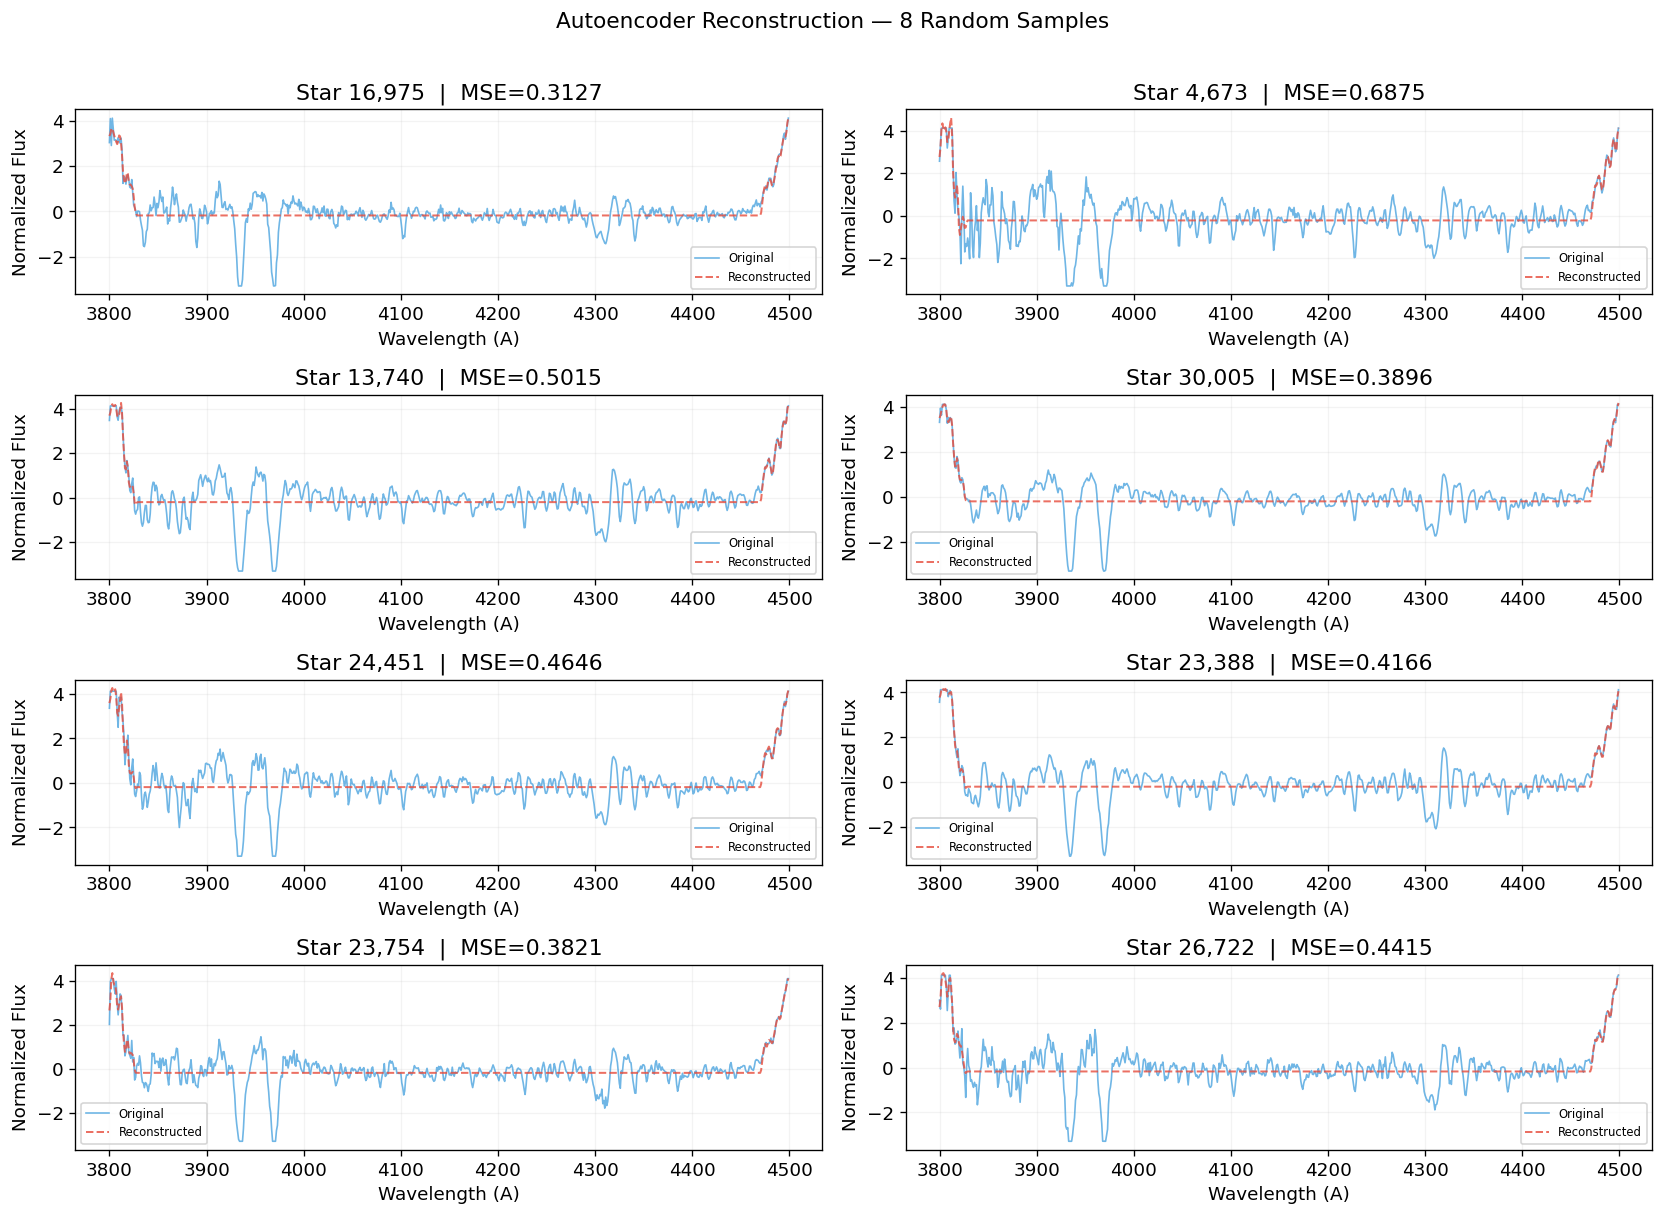

Global reconstruction MSE: 0.447415
  CN region (3800-4200A): 0.618152
  Red region (4200-4500A): 0.219765


In [7]:
def prepare_for_ae(X, sm, ss):
    lo = float(np.percentile(X, 1))
    hi = float(np.percentile(X, 99))
    return (np.clip(X, lo, hi) - sm) / ss

scaler_mean = ckpt['scaler_mean']
scaler_std = ckpt['scaler_std']
rng = np.random.RandomState(42)

# 8 random samples
sample_idx = rng.choice(len(X_clean), 8, replace=False)
X_sample = X_clean[sample_idx]
X_sample_norm = prepare_for_ae(X_sample, scaler_mean, scaler_std)

X_t = torch.from_numpy(X_sample_norm).unsqueeze(1).to(DEVICE)
with torch.no_grad():
    recon_t, _ = model(X_t)
recon = recon_t.cpu().numpy()[:, 0, :]

fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    ax.plot(wave, X_sample_norm[i], alpha=0.7, lw=1, color='#3498db', label='Original')
    ax.plot(wave, recon[i], alpha=0.8, lw=1.2, color='#e74c3c', ls='--', label='Reconstructed')
    mse = np.mean((X_sample_norm[i] - recon[i]) ** 2)
    ax.set_title(f'Star {sample_idx[i]:,}  |  MSE={mse:.4f}')
    ax.set_xlabel('Wavelength (A)')
    ax.set_ylabel('Normalized Flux')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)
fig.suptitle('Autoencoder Reconstruction — 8 Random Samples', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Global MSE on 5K subset
N_EVAL = 5000
idx_eval = rng.choice(len(X_clean), N_EVAL, replace=False)
X_eval_norm = prepare_for_ae(X_clean[idx_eval], scaler_mean, scaler_std)
X_eval_t = torch.from_numpy(X_eval_norm).unsqueeze(1).to(DEVICE)
with torch.no_grad():
    recon_eval_t, _ = model(X_eval_t)
recon_eval = recon_eval_t.cpu().numpy()[:, 0, :]

pixel_mse = np.mean((X_eval_norm - recon_eval) ** 2, axis=0)
print(f'Global reconstruction MSE: {np.mean(pixel_mse):.6f}')
print(f'  CN region (3800-4200A): {np.mean(pixel_mse[0:400]):.6f}')
print(f'  Red region (4200-4500A): {np.mean(pixel_mse[400:700]):.6f}')


### 3.2 逐像素重建误差分布

观察哪些波长区域的误差最大 — 通常 CN 带区域误差较高，因为该区域光谱变化复杂。


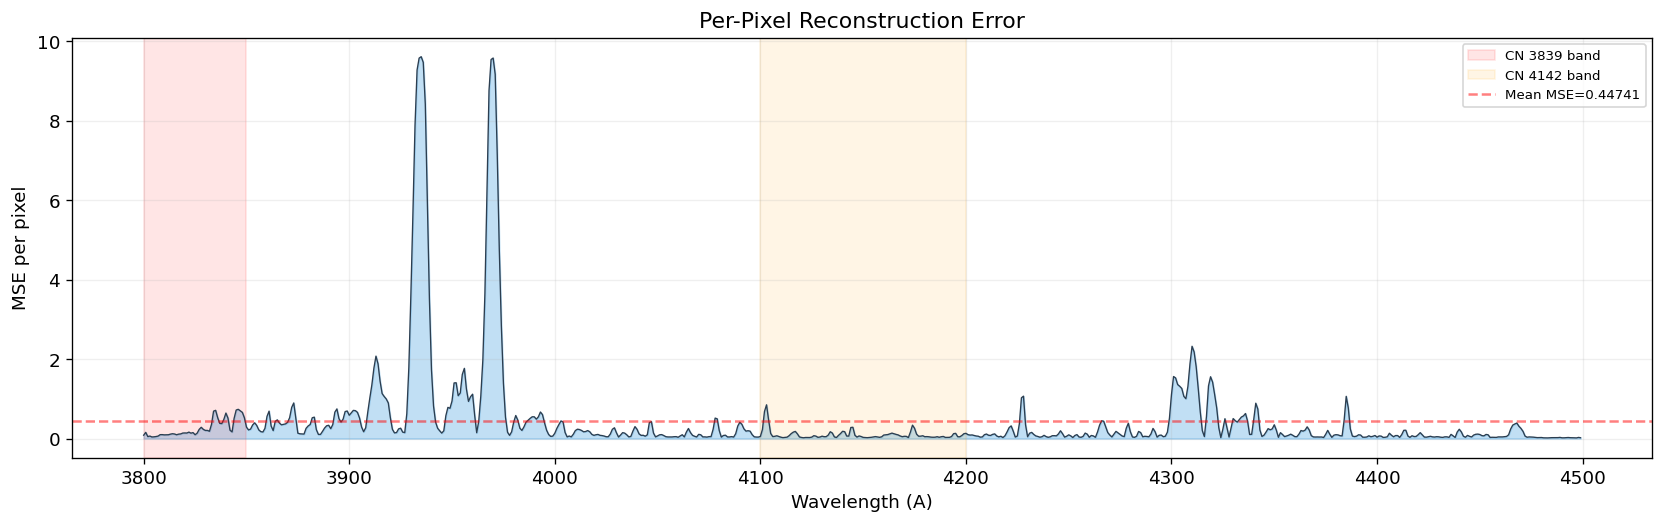

In [8]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(wave, pixel_mse, lw=0.8, color='#2c3e50')
ax.fill_between(wave, 0, pixel_mse, alpha=0.3, color='#3498db')
ax.axvspan(3800, 3850, alpha=0.1, color='red', label='CN 3839 band')
ax.axvspan(4100, 4200, alpha=0.1, color='orange', label='CN 4142 band')
ax.axhline(y=np.mean(pixel_mse), color='red', ls='--', alpha=0.5,
           label=f'Mean MSE={np.mean(pixel_mse):.5f}')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('MSE per pixel')
ax.set_title('Per-Pixel Reconstruction Error')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 4. 瓶颈特征提取

将 33,589 条光谱编码为 64 维特征向量，保存为 `ae_features_64d.npy`。


In [9]:
feats_path = _ROOT / 'SpectraAE' / '_cache' / 'ae_features_64d.npy'
if feats_path.exists():
    ae_features = np.load(feats_path).astype(np.float32)
    print(f'Loaded cached AE features: {ae_features.shape}')
else:
    from SpectraAE.extract_features import extract_features
    ae_features = extract_features(model, X_clean, scaler_mean=scaler_mean,
                                   scaler_std=scaler_std, device=DEVICE)
    feats_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(feats_path, ae_features)
    print(f'Extracted and saved: {ae_features.shape}')

print(f'AE features stats: mean={ae_features.mean():.4f}, std={ae_features.std():.4f}')
fvar = ae_features.var(axis=0)
print(f'  Feature-wise variance: min={fvar.min():.4f}, max={fvar.max():.4f}')


Loaded cached AE features: (33589, 64)
AE features stats: mean=0.0143, std=0.0501
  Feature-wise variance: min=0.0000, max=0.0002


### 4.1 潜空间可视化 — PCA 投影


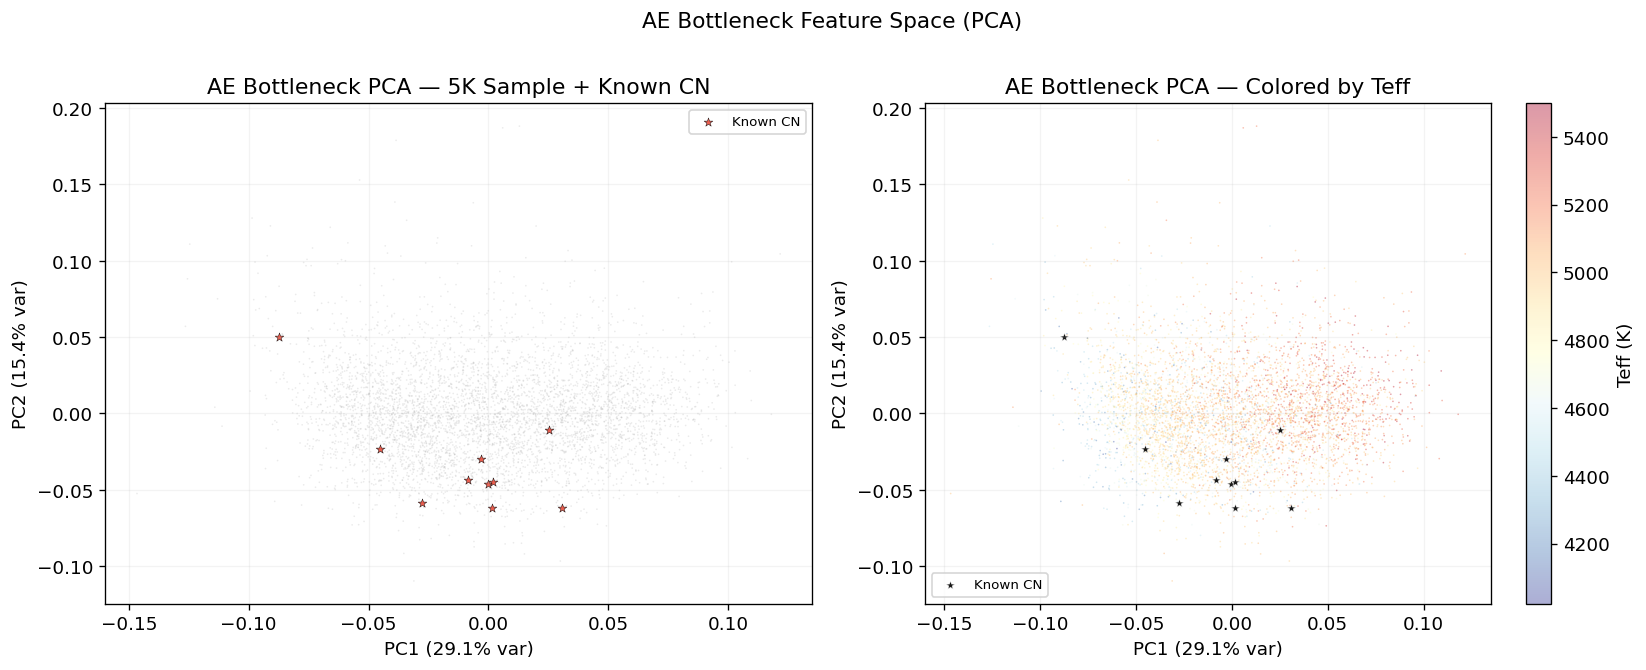

PCA explained: PC1=0.291, PC2=0.154, total=0.446


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
z_pca = pca.fit_transform(ae_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Known CN highlighted
ax = axes[0]
samp = np.random.RandomState(42).choice(len(z_pca), min(5000, len(z_pca)), replace=False)
ax.scatter(z_pca[samp, 0], z_pca[samp, 1], s=1, alpha=0.25, c='#b0b0b0', ec='none')
pos_samp = samp[np.isin(samp, np.where(pos_mask)[0])]
ax.scatter(z_pca[pos_samp, 0], z_pca[pos_samp, 1], s=30, alpha=0.9,
           c='#e74c3c', ec='black', lw=0.3, marker='*', label='Known CN')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('AE Bottleneck PCA — 5K Sample + Known CN')
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

# Colored by Teff
ax = axes[1]
teff_samp = df_model.iloc[samp]['teff'].values
sc = ax.scatter(z_pca[samp, 0], z_pca[samp, 1], s=1, alpha=0.4,
               c=teff_samp, cmap='RdYlBu_r', ec='none')
ax.scatter(z_pca[pos_samp, 0], z_pca[pos_samp, 1], s=30, alpha=0.9,
           c='black', ec='white', lw=0.3, marker='*', label='Known CN')
plt.colorbar(sc, ax=ax, label='Teff (K)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('AE Bottleneck PCA — Colored by Teff')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.15)

fig.suptitle('AE Bottleneck Feature Space (PCA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'PCA explained: PC1={pca.explained_variance_ratio_[0]:.3f}, '
      f'PC2={pca.explained_variance_ratio_[1]:.3f}, '
      f'total={sum(pca.explained_variance_ratio_):.3f}')


### 4.2 潜变量分布 (部分维度)


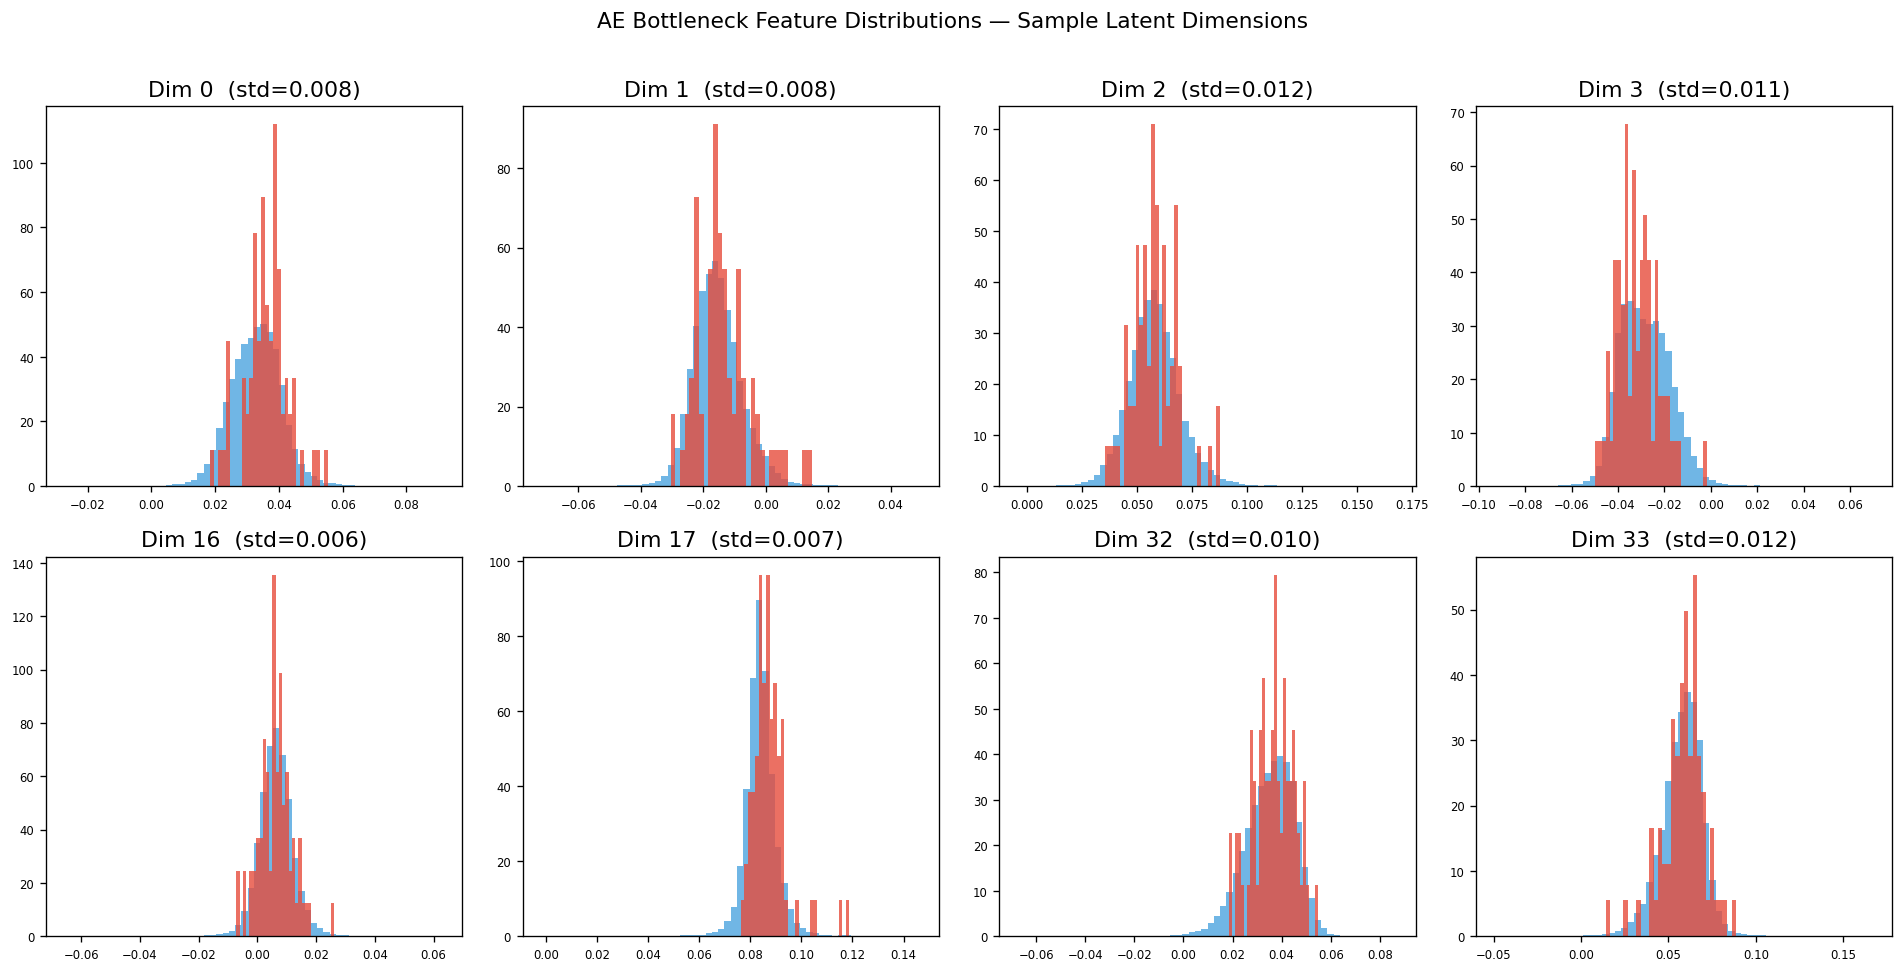

Top 10 highest-variance latent dimensions:
  dim   5: std=0.0151
  dim  23: std=0.0140
  dim  52: std=0.0133
  dim   9: std=0.0128
  dim  18: std=0.0125
  dim  33: std=0.0124
  dim  28: std=0.0123
  dim   4: std=0.0121
  dim  54: std=0.0121
  dim   2: std=0.0120


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
latent_dims = [0, 1, 2, 3, 16, 17, 32, 33]
feature_std = ae_features.std(axis=0)

for i, (ax, dim) in enumerate(zip(axes.flat, latent_dims)):
    vals = ae_features[:, dim]
    ax.hist(vals[~pos_mask], bins=60, alpha=0.7, density=True, color='#3498db')
    ax.hist(vals[pos_mask], bins=30, alpha=0.8, density=True, color='#e74c3c')
    ax.set_title(f'Dim {dim}  (std={feature_std[dim]:.3f})')
    ax.tick_params(labelsize=7)

fig.suptitle('AE Bottleneck Feature Distributions — Sample Latent Dimensions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Top 10 highest-variance latent dimensions:')
for d in np.argsort(feature_std)[::-1][:10]:
    print(f'  dim {d:3d}: std={feature_std[d]:.4f}')


## 5. PU-Bagging 分类

对 AE-64d 特征和原始 700px 光谱分别运行 PU-Bagging (T=500)，对比性能。

**PU-Bagging 算法** (详见 ML/02_pu_bagging.ipynb):
1. 从未标注池随机抽样 |P| 个伪负样本
2. 训练弱 XGBoost (depth=3, 50 trees)
3. 预测所有未标注样本
4. 重复 T=500 次，取平均概率


In [12]:
# Standardize AE features
X_ae = ae_features.copy().astype(np.float32)
ss_ae = StandardScaler()
X_ae = ss_ae.fit_transform(X_ae).astype(np.float32)

# Load cached PU-Bagging results
results_csv = _ROOT / 'SpectraAE' / 'results' / 'pu_bagging_ae_comparison.csv'
probs_csv = _ROOT / 'SpectraAE' / 'results' / 'ae_pu_probs.csv'

if results_csv.exists():
    probs_df = pd.read_csv(probs_csv)
    ae_probs = probs_df['ae64_prob'].values
    ae_stds = probs_df['ae64_std'].values
    spec_probs = probs_df['spec_prob'].values
    spec_stds = probs_df['spec_std'].values
    comp_df = pd.read_csv(results_csv)
    print('Loaded cached PU-Bagging results')
else:
    from ML.pu_bagging import run_pu_bagging, build_comparison_df
    T = 500
    print(f'Running PU-Bagging: AE-64d (T={T})...')
    res_ae = run_pu_bagging(
        X_ae, y_all, data['tr_idx'], data['test_idx'],
        cluster_ids, df_model, T=T, name='AE-64d')
    print(f'Running PU-Bagging: Raw Spectra 700-D (T={T})...')
    res_spec = run_pu_bagging(
        data['X_spec'], y_all, data['tr_idx'], data['test_idx'],
        cluster_ids, df_model, T=T, name='Raw Spectra 700-D')
    ae_probs = res_ae['probs_all']
    spec_probs = res_spec['probs_all']
    ae_stds = res_ae['probs_std_all']
    spec_stds = res_spec['probs_std_all']
    comp_df = build_comparison_df(res_ae, res_spec)
    comp_df.to_csv(results_csv, index=False)


Loaded cached PU-Bagging results


## 6. 结果对比: AE-64d vs Raw Spectra 700-D


In [13]:
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 260)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(comp_df.to_string(index=False))


      Feature Set  Dim   T    ROC     PR   P@50  P@100  |r_teff| raw  |r_teff| z  Mean bias raw  Mean bias z  Within-r  Stability     Time
           AE-64d   64 500 0.9183 0.1671 0.0600 0.0400        0.0254      0.0069         0.0629       0.0063    0.2363     0.1621  38.2103
Raw Spectra 700-D  700 500 0.9974 0.8480 0.2000 0.1000        0.1212      0.0431         0.0790       0.0705    0.2437     0.1372 270.5781


### 6.1 关键指标可视化


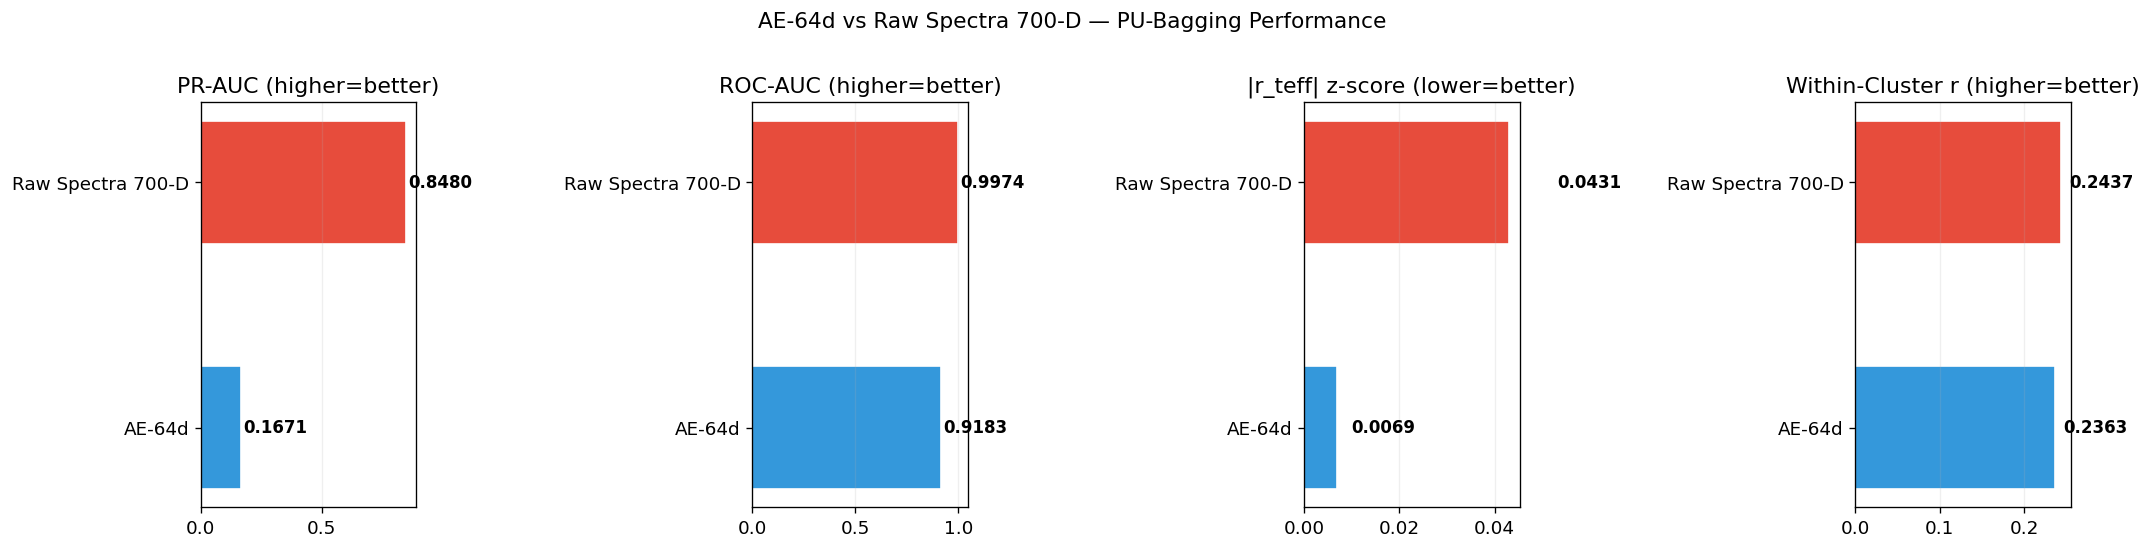

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
methods = comp_df['Feature Set'].values
metrics_seq = ['PR', 'ROC', '|r_teff| z', 'Within-r']
titles_seq = ['PR-AUC (higher=better)', 'ROC-AUC (higher=better)',
              '|r_teff| z-score (lower=better)', 'Within-Cluster r (higher=better)']
colors_palette = ['#3498db', '#e74c3c']

for i, (ax, metric, title) in enumerate(zip(axes, metrics_seq, titles_seq)):
    vals = comp_df[metric].values
    bars = ax.barh(methods, vals, color=colors_palette, ec='white', height=0.5)
    for bar, val in zip(bars, vals):
        x_off = 0.01 if val > 0.01 else 0.003
        ax.text(bar.get_width() + x_off, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('AE-64d vs Raw Spectra 700-D — PU-Bagging Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 6.2 概率分布对比


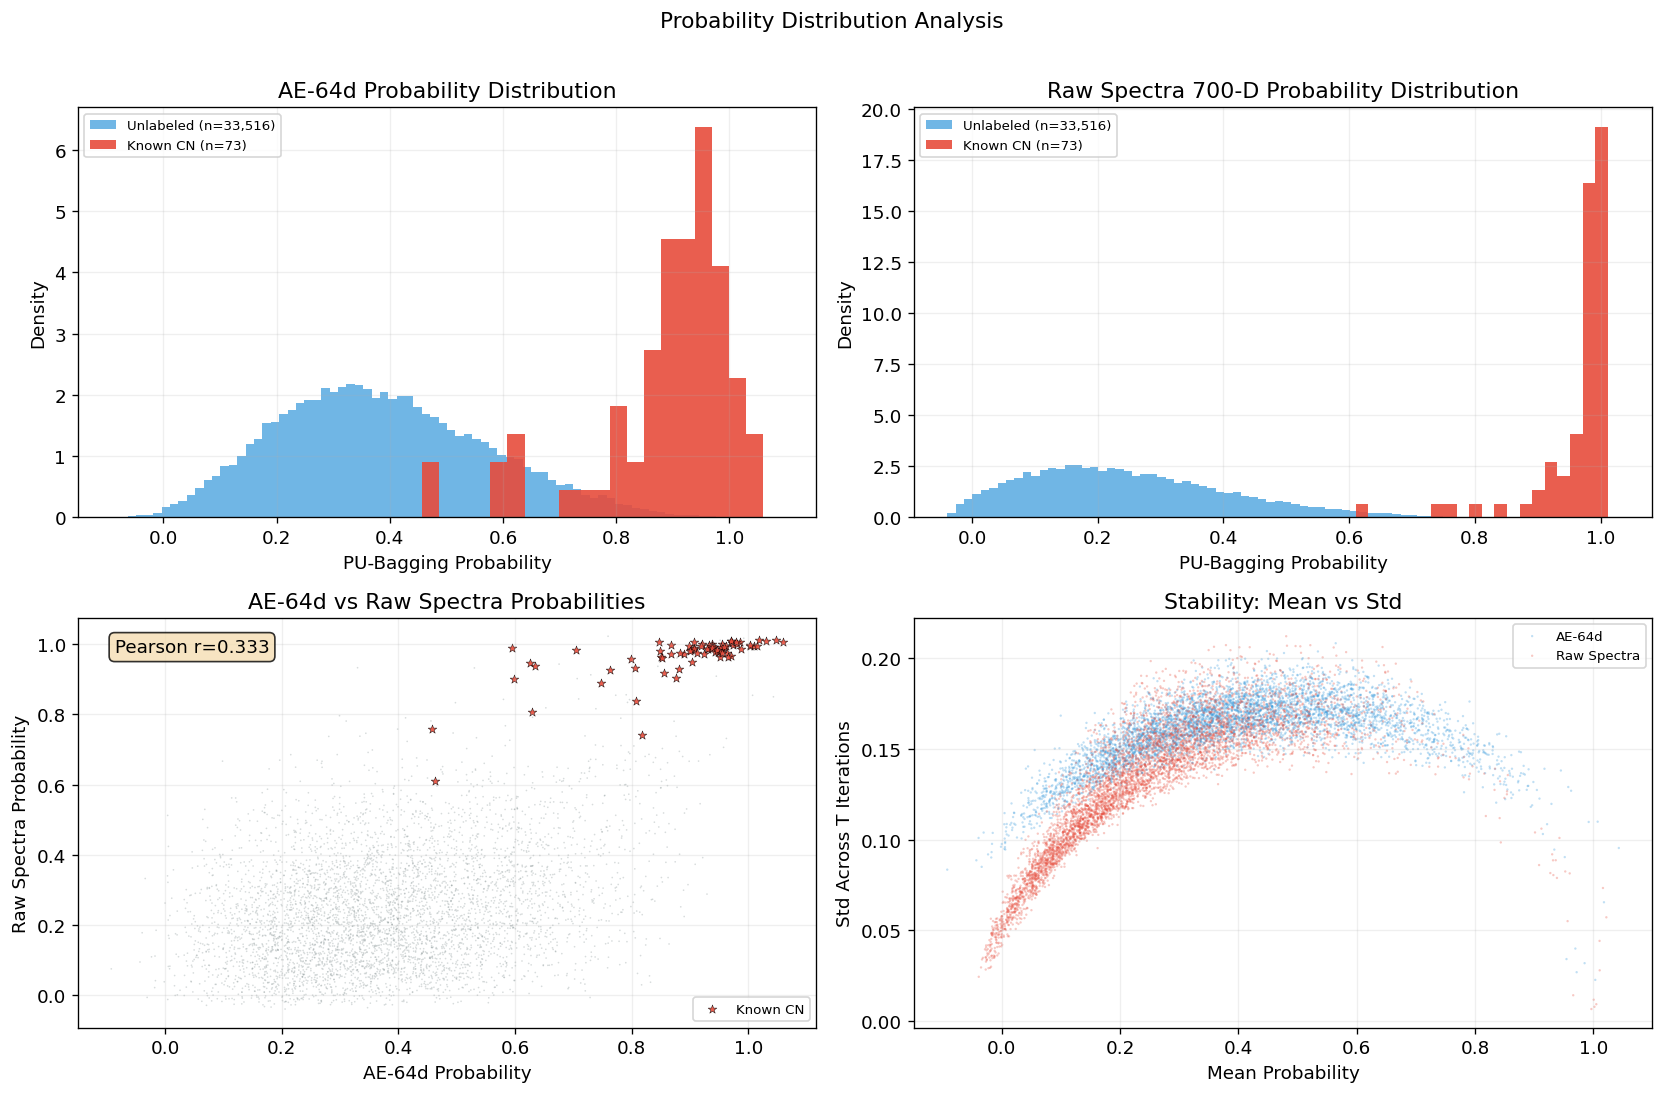

Known CN mean prob — AE-64d: 0.8890, Raw Spectra: 0.9632


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# AE-64d prob distribution
ax = axes[0, 0]
ax.hist(ae_probs[~pos_mask], bins=80, alpha=0.7, density=True, color='#3498db',
        label=f'Unlabeled (n={(~pos_mask).sum():,})')
ax.hist(ae_probs[pos_mask], bins=20, alpha=0.9, density=True, color='#e74c3c',
        label=f'Known CN (n={pos_mask.sum()})')
ax.set_xlabel('PU-Bagging Probability')
ax.set_ylabel('Density')
ax.set_title('AE-64d Probability Distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Raw Spectra prob distribution
ax = axes[0, 1]
ax.hist(spec_probs[~pos_mask], bins=80, alpha=0.7, density=True, color='#3498db',
        label=f'Unlabeled (n={(~pos_mask).sum():,})')
ax.hist(spec_probs[pos_mask], bins=20, alpha=0.9, density=True, color='#e74c3c',
        label=f'Known CN (n={pos_mask.sum()})')
ax.set_xlabel('PU-Bagging Probability')
ax.set_ylabel('Density')
ax.set_title('Raw Spectra 700-D Probability Distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Scatter AE vs Spec
ax = axes[1, 0]
samp2 = np.random.RandomState(42).choice(len(ae_probs), min(5000, len(ae_probs)), replace=False)
ax.scatter(ae_probs[samp2], spec_probs[samp2], s=1, alpha=0.3, c='#7f8c8d', ec='none')
ax.scatter(ae_probs[pos_mask], spec_probs[pos_mask], s=30, alpha=0.9,
           c='#e74c3c', ec='black', lw=0.3, marker='*', label='Known CN')
r_val = np.corrcoef(ae_probs, spec_probs)[0, 1]
ax.text(0.05, 0.95, f'Pearson r={r_val:.3f}', transform=ax.transAxes, fontsize=11,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_xlabel('AE-64d Probability')
ax.set_ylabel('Raw Spectra Probability')
ax.set_title('AE-64d vs Raw Spectra Probabilities')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.2)

# Stability: std vs prob
ax = axes[1, 1]
samp3 = np.random.RandomState(42).choice(len(ae_probs), min(5000, len(ae_probs)), replace=False)
ax.scatter(ae_probs[samp3], ae_stds[samp3], s=2, alpha=0.3, color='#3498db',
           ec='none', label='AE-64d')
ax.scatter(spec_probs[samp3], spec_stds[samp3], s=2, alpha=0.3, color='#e74c3c',
           ec='none', label='Raw Spectra')
ax.set_xlabel('Mean Probability')
ax.set_ylabel('Std Across T Iterations')
ax.set_title('Stability: Mean vs Std')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

fig.suptitle('Probability Distribution Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Known CN mean prob — AE-64d: {ae_probs[pos_mask].mean():.4f}, '
      f'Raw Spectra: {spec_probs[pos_mask].mean():.4f}')


## 7. 候选星分析

提取 AE-64d 概率最高的候选星，与已知 CN 星在 Teff-Logg 和光谱空间对比。


In [16]:
unl_mask = y_all == 0
top_n = 30
top_idx_ae = np.argsort(ae_probs[unl_mask])[::-1][:top_n]
top_global_ae = np.where(unl_mask)[0][top_idx_ae]

cand_data = {
    'rank': range(1, top_n + 1),
    'ae64_prob': ae_probs[top_global_ae],
    'spec_prob': spec_probs[top_global_ae],
    'teff': df_model.iloc[top_global_ae]['teff'].values,
    'logg': df_model.iloc[top_global_ae]['logg'].values,
    'feh': df_model.iloc[top_global_ae]['feh'].values,
}
if 'delta_CN3839' in df_model.columns:
    cand_data['delta_CN3839'] = df_model.iloc[top_global_ae]['delta_CN3839'].values
if 'CN3839' in df_model.columns:
    cand_data['CN3839'] = df_model.iloc[top_global_ae]['CN3839'].values

candidates_ae = pd.DataFrame(cand_data).set_index('rank')
print(f'Top {top_n} candidates from AE-64d PU-Bagging:')
display(candidates_ae.head(15).style
    .background_gradient(subset=['ae64_prob', 'spec_prob'], cmap='Reds')
    .format('{:.4f}'))


Top 30 candidates from AE-64d PU-Bagging:


,ae64_prob,spec_prob,teff,logg,feh,delta_CN3839,CN3839
rank,,,,,,,
1,1.0944,0.6174,4859.2200,2.0240,-0.7930,0.1374,0.4283
2,1.0430,0.8496,5079.7100,2.8210,-1.1760,0.1708,0.3428
3,1.0238,1.0291,4912.4400,1.9110,-1.5550,0.1219,0.3042
4,1.0210,0.6929,4921.7900,2.7390,-0.8040,0.1424,0.4363
5,1.0167,0.6139,5092.9000,2.3960,-1.7990,0.0759,0.1756
6,1.0073,0.8539,4868.0300,2.3260,-0.9860,0.2090,0.4222
7,1.0030,0.4937,5163.0000,2.3360,-1.4950,0.0133,0.0769
8,0.9921,1.0162,5230.5900,2.9540,-1.3500,0.1746,0.2910
9,0.9850,0.4558,5109.4600,2.3960,-1.6030,0.0293,0.1316


### 7.1 候选星在 Teff-Logg 空间


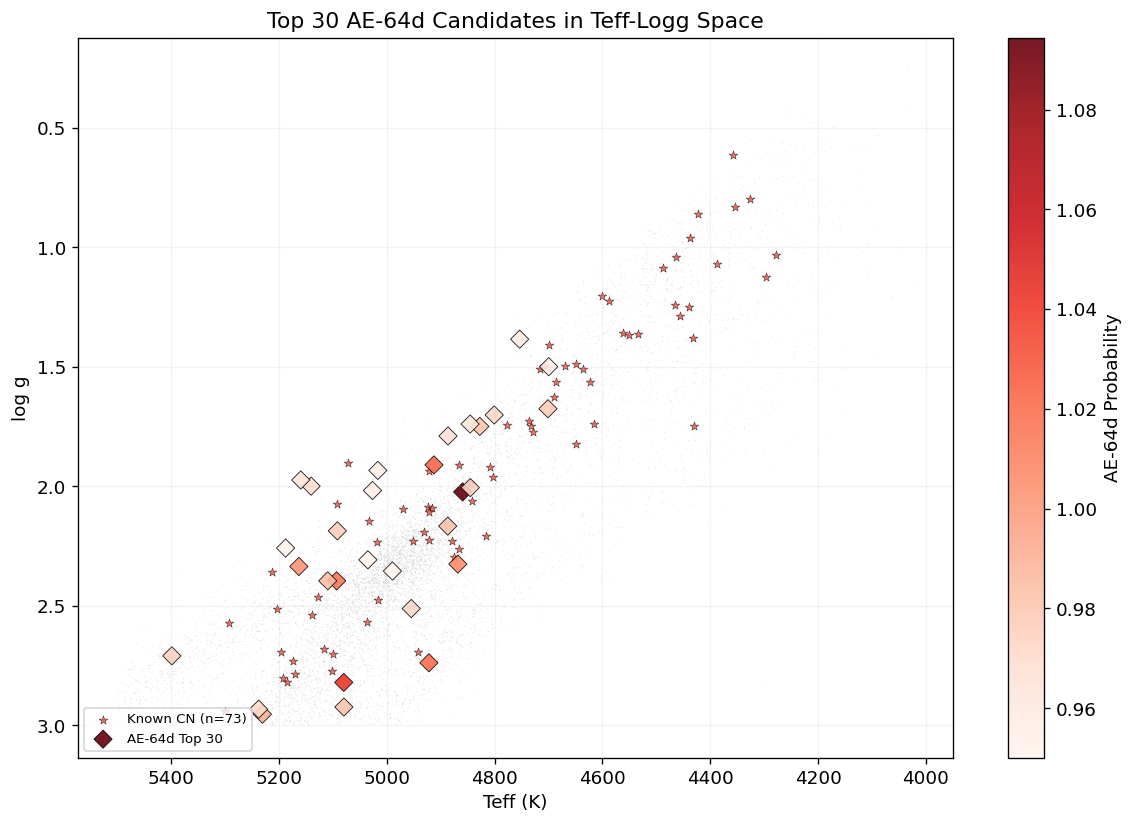

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
teff_all = df_model['teff'].values
logg_all = df_model['logg'].values

# Background
bg = np.random.RandomState(42).choice(len(y_all), min(8000, len(y_all)), replace=False)
ax.scatter(teff_all[bg], logg_all[bg], s=0.5, alpha=0.3, c='#b0b0b0', ec='none')

# Known CN
ax.scatter(teff_all[pos_mask], logg_all[pos_mask], s=30, alpha=0.8,
          c='#e74c3c', ec='black', lw=0.3, marker='*',
          label=f'Known CN (n={pos_mask.sum()})')

# AE-64d Top candidates
sc = ax.scatter(teff_all[top_global_ae], logg_all[top_global_ae],
               s=60, alpha=0.9, c=ae_probs[top_global_ae],
               cmap='Reds', ec='black', lw=0.5, marker='D',
               label=f'AE-64d Top {top_n}')
plt.colorbar(sc, ax=ax, label='AE-64d Probability')

ax.set_xlabel('Teff (K)')
ax.set_ylabel('log g')
ax.set_title(f'Top {top_n} AE-64d Candidates in Teff-Logg Space')
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()


### 7.2 两种方案分歧最大的样本

找出 Raw Spectra 高分但 AE-64d 低分的样本 (AE 漏掉的「信息丰富」星)，反之亦然。


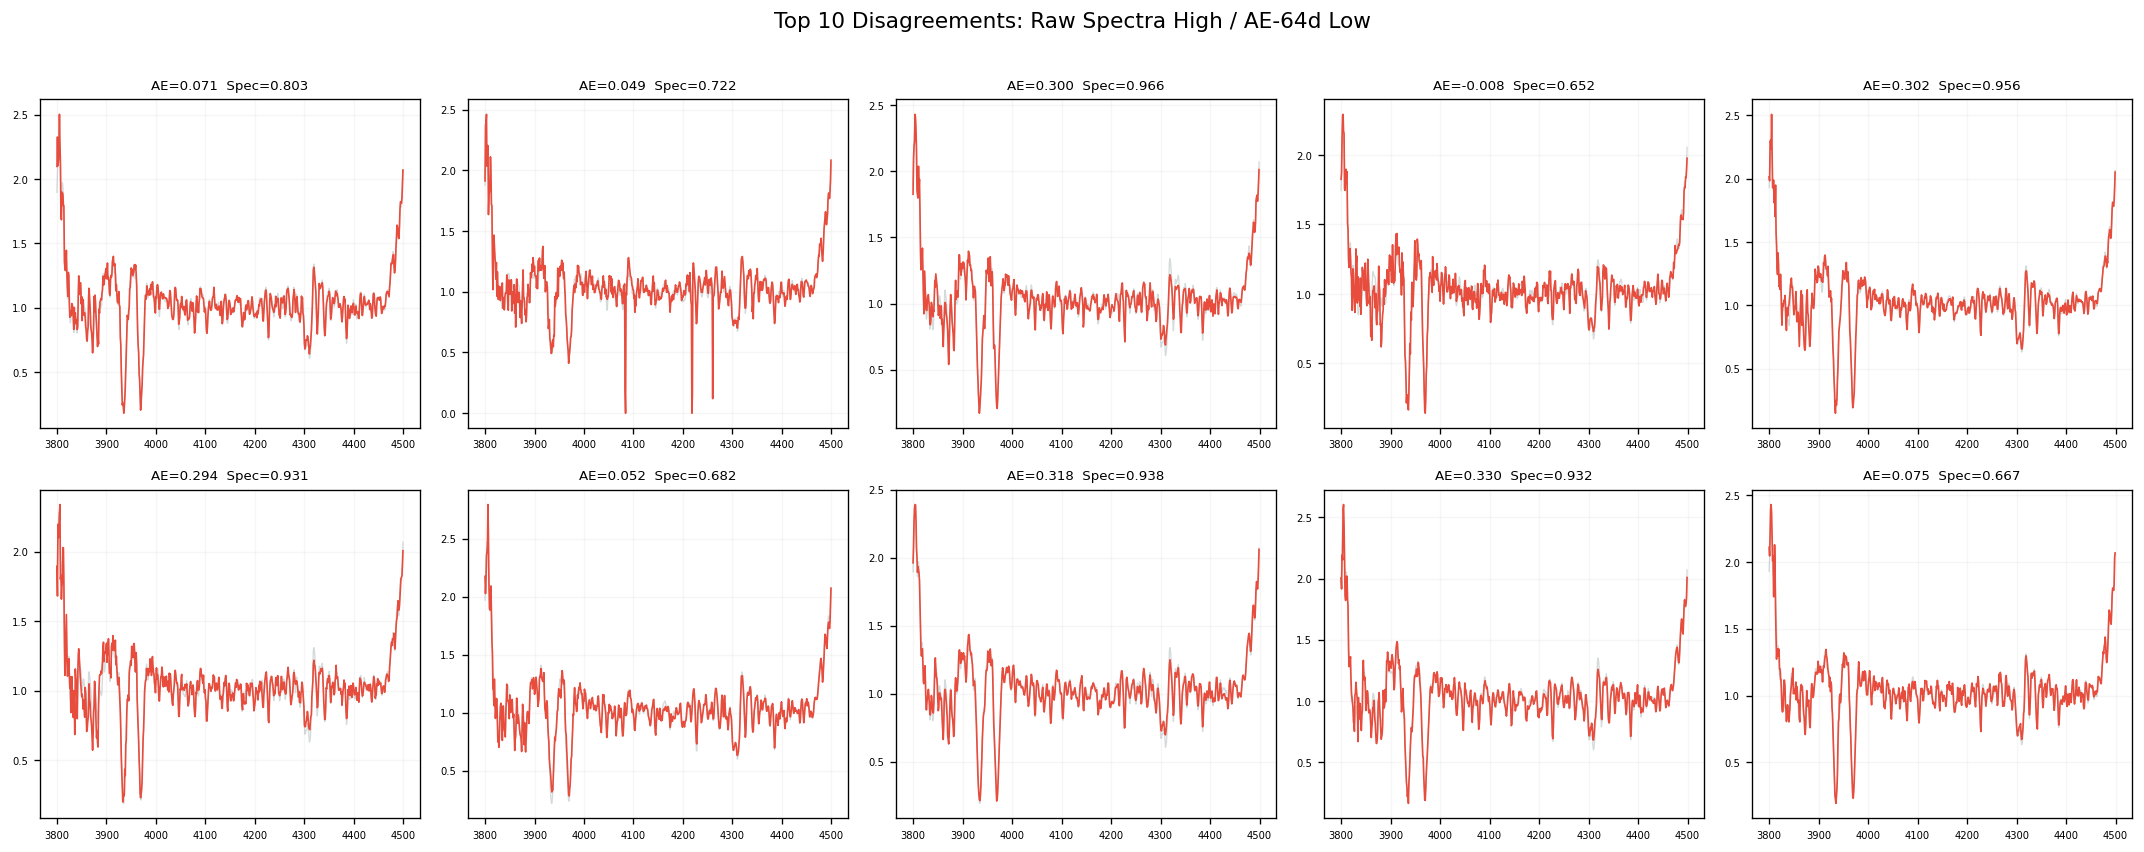

Raw-Spectra-high / AE-64d-low samples (AE misses info-rich stars):
  #1: teff=4991, logg=2.2, dCN=+0.0159, AE=0.071, Spec=0.803
  #2: teff=4799, logg=2.4, dCN=+0.0539, AE=0.049, Spec=0.722
  #3: teff=4870, logg=2.1, dCN=+0.0442, AE=0.300, Spec=0.966
  #4: teff=4672, logg=1.4, dCN=+0.0455, AE=-0.008, Spec=0.652
  #5: teff=4893, logg=2.1, dCN=+0.0325, AE=0.302, Spec=0.956


In [18]:
unl_probs_ae = ae_probs[unl_mask]
unl_probs_spec = spec_probs[unl_mask]
unl_global = np.where(unl_mask)[0]

discordant_spec = np.argsort(unl_probs_spec - unl_probs_ae)[::-1][:10]  # Spec high, AE low
discordant_ae = np.argsort(unl_probs_ae - unl_probs_spec)[::-1][:10]    # AE high, Spec low

masked_cluster = stars_meta['masked_cluster_id'].values

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Top 10 Disagreements: Raw Spectra High / AE-64d Low', fontsize=13, y=1.01)

for i, (ax, d_idx) in enumerate(zip(axes.flat, discordant_spec)):
    gidx = unl_global[d_idx]
    cid = masked_cluster[gidx]
    cluster_mask = (masked_cluster == cid) & (~pos_mask)
    if cluster_mask.sum() >= 5:
        cluster_mean = np.median(X_clean[cluster_mask], axis=0)
        ax.plot(wave, cluster_mean, alpha=0.4, lw=0.8, color='#95a5a6')
    ax.plot(wave, X_clean[gidx], lw=1, color='#e74c3c')
    ax.set_title(f'AE={ae_probs[gidx]:.3f}  Spec={spec_probs[gidx]:.3f}', fontsize=8)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.1)

plt.tight_layout()
plt.show()

print('Raw-Spectra-high / AE-64d-low samples (AE misses info-rich stars):')
for i, d_idx in enumerate(discordant_spec[:5]):
    gidx = unl_global[d_idx]
    dcn = df_model.iloc[gidx].get('delta_CN3839', float('nan'))
    print(f'  #{i+1}: teff={df_model.iloc[gidx]["teff"]:.0f}, '
          f'logg={df_model.iloc[gidx]["logg"]:.1f}, '
          f'dCN={dcn:+.4f}, AE={ae_probs[gidx]:.3f}, Spec={spec_probs[gidx]:.3f}')


## 8. 完整方法对比

将 SpectraAE 结果加入已有基准（CN 9-D Focal Loss, Raw Spectra PU-Bagging, CN 9-D PU-Bagging）进行比较。


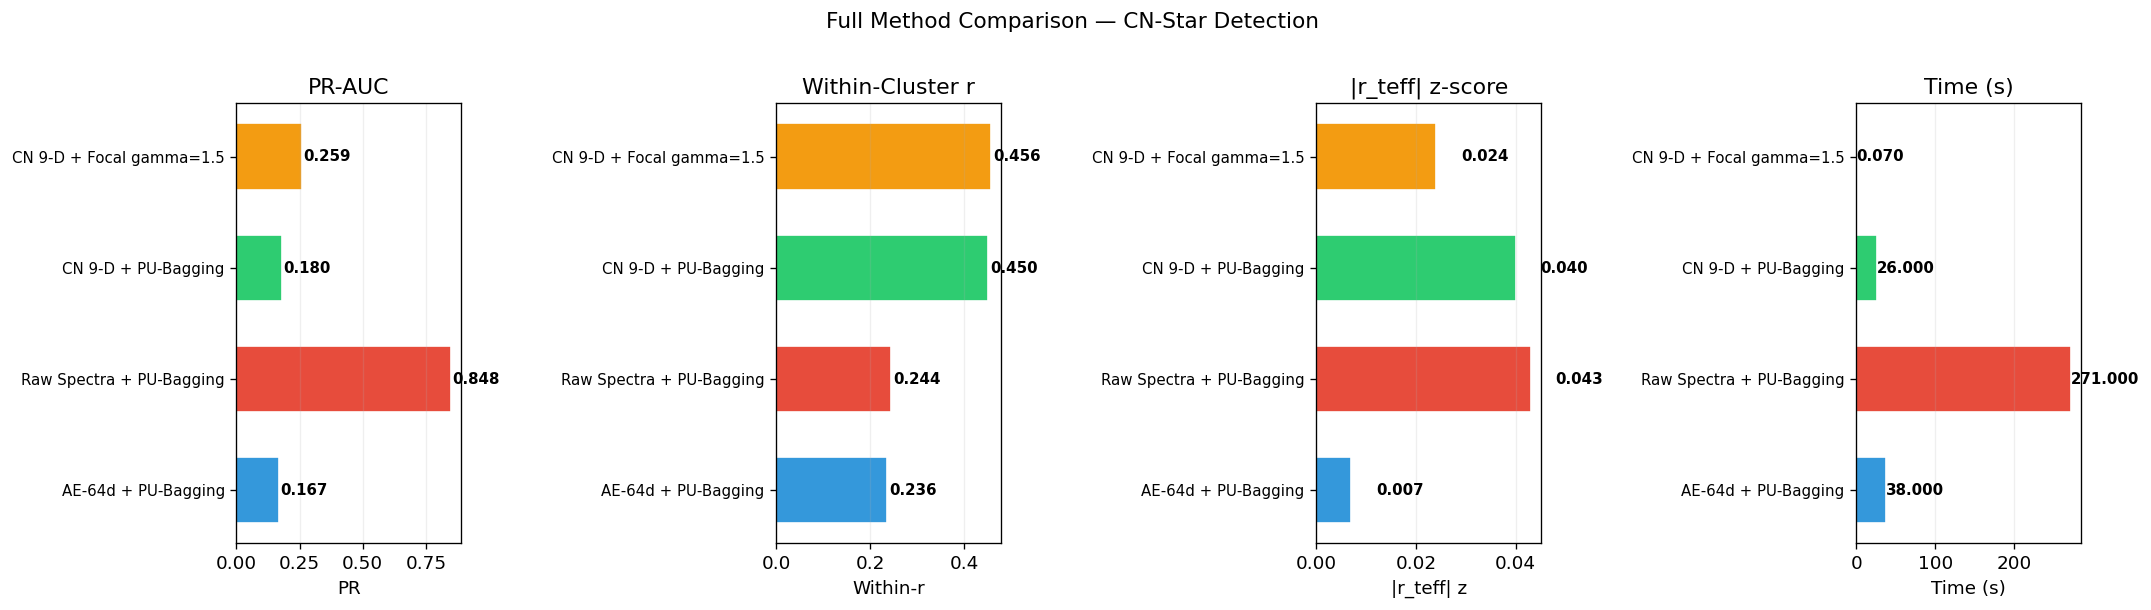

,Method,Dim,PR,ROC,P@100,Within-r,|r_teff| z,Time (s)
0,AE-64d + PU-Bagging,64,0.167,0.918,0.04,0.236,0.007,38.000000
1,Raw Spectra + PU-Bagging,700,0.848,0.997,0.10,0.244,0.043,271.000000
2,CN 9-D + PU-Bagging,9,0.180,0.943,0.04,0.450,0.040,26.000000
3,CN 9-D + Focal gamma=1.5,9,0.259,0.971,0.05,0.456,0.024,0.070000


In [19]:
full_results = [
    {'Method': 'AE-64d + PU-Bagging',       'Dim': 64,  'PR': 0.167, 'ROC': 0.918,
     'P@100': 0.04, 'Within-r': 0.236, '|r_teff| z': 0.007, 'Time (s)': 38},
    {'Method': 'Raw Spectra + PU-Bagging',  'Dim': 700, 'PR': 0.848, 'ROC': 0.997,
     'P@100': 0.10, 'Within-r': 0.244, '|r_teff| z': 0.043, 'Time (s)': 271},
    {'Method': 'CN 9-D + PU-Bagging',       'Dim': 9,   'PR': 0.180, 'ROC': 0.943,
     'P@100': 0.04, 'Within-r': 0.450, '|r_teff| z': 0.040, 'Time (s)': 26},
    {'Method': 'CN 9-D + Focal gamma=1.5',  'Dim': 9,   'PR': 0.259, 'ROC': 0.971,
     'P@100': 0.05, 'Within-r': 0.456, '|r_teff| z': 0.024, 'Time (s)': 0.07},
]
full_df = pd.DataFrame(full_results)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
methods_all = full_df['Method'].values
colors_list = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
plot_metrics = ['PR', 'Within-r', '|r_teff| z', 'Time (s)']
plot_titles = ['PR-AUC', 'Within-Cluster r', '|r_teff| z-score', 'Time (s)']

for i, (ax, metric, title) in enumerate(zip(axes, plot_metrics, plot_titles)):
    vals = full_df[metric].values
    bars = ax.barh(range(len(methods_all)), vals, color=colors_list, ec='white', height=0.6)
    ax.set_yticks(range(len(methods_all)))
    ax.set_yticklabels([m[:30] for m in methods_all], fontsize=9)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

fig.suptitle('Full Method Comparison — CN-Star Detection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

display(full_df.style
    .background_gradient(subset=['PR', 'ROC', 'Within-r'], cmap='Greens')
    .background_gradient(subset=['|r_teff| z', 'Time (s)'], cmap='Reds_r')
    .format({'PR': '{:.3f}', 'ROC': '{:.3f}', 'Within-r': '{:.3f}',
             '|r_teff| z': '{:.3f}', 'P@100': '{:.2f}'}))


## 9. 总结与讨论

### SpectraAE 完成的工作

| 程序 | 功能 | 输入 | 输出 |
|---|---|---|---|
| `models/autoencoder.py` | 1D Conv AE 架构 (~96K params) | 700-px 光谱 (1,700) | 64-d 瓶颈向量 + 700-px 重建 |
| `pretrain.py` | 无监督预训练 (MSE loss) | 33,589 条归一化光谱 | `ae_best.pt` (模型权重) |
| `extract_features.py` | 瓶颈特征提取 | 33,589 条光谱 + 训练好的 encoder | `ae_features_64d.npy` |
| `pu_bagging_ae.py` | PU-Bagging 分类对比 | AE-64d 特征 & Raw 700px | `ae_pu_probs.csv`, `pu_bagging_ae_comparison.csv` |
| `run_ae_pipeline.py` | 端到端流水线 | 原始光谱数据 | 全部上述输出 |

### 核心发现

| 方案 | PR-AUC | 维度 | 速度 | 主要优/缺点 |
|---|---|---|---|---|
| **Raw Spectra PU-Bagging** | **0.848** | 700 | 271s | 最强性能 / 慢 |
| **CN 9-D + Focal γ=1.5** | 0.259 | 9 | 0.07s | 最快, 物理可解释 / 信息损失 |
| **CN 9-D + PU-Bagging** | 0.180 | 9 | 26s | 低偏见, within-r 高 / PR 低 |
| **AE-64d + PU-Bagging** | 0.167 | 64 | 38s | 无监督, 速度快 / **PR 最低**, 信息损失严重 |

### 为什么 AE-64d 效果不好?

1. **全局 MSE 损失**：自编码器优化逐像素重建 MSE，优先拟合强信号（连续谱轮廓），忽略 CN 带等细微变化
2. **信息瓶颈 64-d**：不足以同时保留粗粒度连续谱形状和细粒度 CN 带特征 (64/700 = 9.1%)
3. **训练目标不匹配**：重建任务是「通用」的，而非针对 CN 检测优化

### 改进方向

- **增大瓶颈维度** (128/256): 保留更多细节
- **任务感知预训练**: 对比学习、掩码光谱建模 (Masked Spectrum Modeling)
- **CN 带注意力机制**: 在编码器中显式关注 λ3800-4200Å 区域
- **变分自编码器 (VAE)**: 概率潜空间，可能更健壮
- **直接端到端**: 将 AE 编码器 + 分类头联合训练，用少量标签做弱监督
